In [28]:
pip install tensorflow

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!unzip "/content/drive/MyDrive/dataset/dataset.zip" -d "/content/drive/MyDrive/dataset/"

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_1020.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_0458.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_0504.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_0262.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_0276.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_1168.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_0510.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_0538.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_1140.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_1154.jpg  
  inflating: /content/drive/MyDrive/dataset/dataset/Training/notumor/Tr-no_1183.jpg  
  i

# Import Libraries

In [2]:
#OS libs
import os
import shutil
import itertools
import pathlib
from PIL import Image

#Data handling tools
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('whitegrid')
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report

#Deep learning libs
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D , MaxPooling2D , Flatten , Activation , Dense , Dropout , BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

#Warningds
import warnings
warnings.filterwarnings('ignore')

In [15]:
train_data_path = "/content/drive/MyDrive/dataset/dataset/Training"

filepaths = []
labels = []

folds = os.listdir(train_data_path)

for fold in folds:
  f_path = os.path.join(train_data_path, fold)
  if os.path.isdir(f_path):
    filelists = os.listdir(f_path)

    for file in filelists:
      filepaths.append(os.path.join(f_path, file))
      labels.append(fold)

# Concat data paths with labels
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
train_df = pd.concat([Fseries, Lseries], axis=1)

train_df

,filepaths,labels
0,/content/drive/MyDrive/dataset/dataset/Trainin...,pituitary
1,/content/drive/MyDrive/dataset/dataset/Trainin...,pituitary
2,/content/drive/MyDrive/dataset/dataset/Trainin...,pituitary
3,/content/drive/MyDrive/dataset/dataset/Trainin...,pituitary
4,/content/drive/MyDrive/dataset/dataset/Trainin...,pituitary
...,...,...
5707,/content/drive/MyDrive/dataset/dataset/Trainin...,meningioma
5708,/content/drive/MyDrive/dataset/dataset/Trainin...,meningioma
5709,/content/drive/MyDrive/dataset/dataset/Trainin...,meningioma
5710,/content/drive/MyDrive/dataset/dataset/Trainin...,meningioma


In [16]:
test_data_path = "/content/drive/MyDrive/dataset/dataset/Testing"

filepaths = []
labels = []

folds = os.listdir(test_data_path)

for fold in folds:
  f_path = os.path.join(test_data_path, fold)
  if os.path.isdir(f_path):
    filelists = os.listdir(f_path)

    for file in filelists:
      filepaths.append(os.path.join(f_path, file))
      labels.append(fold)

# Concat data paths with labels
Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')
test_df = pd.concat([Fseries, Lseries], axis=1)

test_df

,filepaths,labels
0,/content/drive/MyDrive/dataset/dataset/Testing...,pituitary
1,/content/drive/MyDrive/dataset/dataset/Testing...,pituitary
2,/content/drive/MyDrive/dataset/dataset/Testing...,pituitary
3,/content/drive/MyDrive/dataset/dataset/Testing...,pituitary
4,/content/drive/MyDrive/dataset/dataset/Testing...,pituitary
...,...,...
1306,/content/drive/MyDrive/dataset/dataset/Testing...,meningioma
1307,/content/drive/MyDrive/dataset/dataset/Testing...,meningioma
1308,/content/drive/MyDrive/dataset/dataset/Testing...,meningioma
1309,/content/drive/MyDrive/dataset/dataset/Testing...,meningioma


In [17]:
valid, test = train_test_split(test_df, train_size=0.5, shuffle=True, random_state=42)

In [34]:
img_size = (224 ,224)
batch_size = 16

tr_gen = ImageDataGenerator()
ts_gen= ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train_df , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode = 'rgb' , shuffle = True , batch_size =batch_size)

valid_gen = ts_gen.flow_from_dataframe(valid , x_col = 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                       class_mode = 'categorical',color_mode = 'rgb' , shuffle= True, batch_size = batch_size)

test_gen = ts_gen.flow_from_dataframe(test , x_col= 'filepaths' , y_col = 'labels' , target_size = img_size ,
                                      class_mode = 'categorical' , color_mode= 'rgb' , shuffle = False , batch_size = batch_size)

Found 5712 validated image filenames belonging to 4 classes.
Found 655 validated image filenames belonging to 4 classes.
Found 656 validated image filenames belonging to 4 classes.


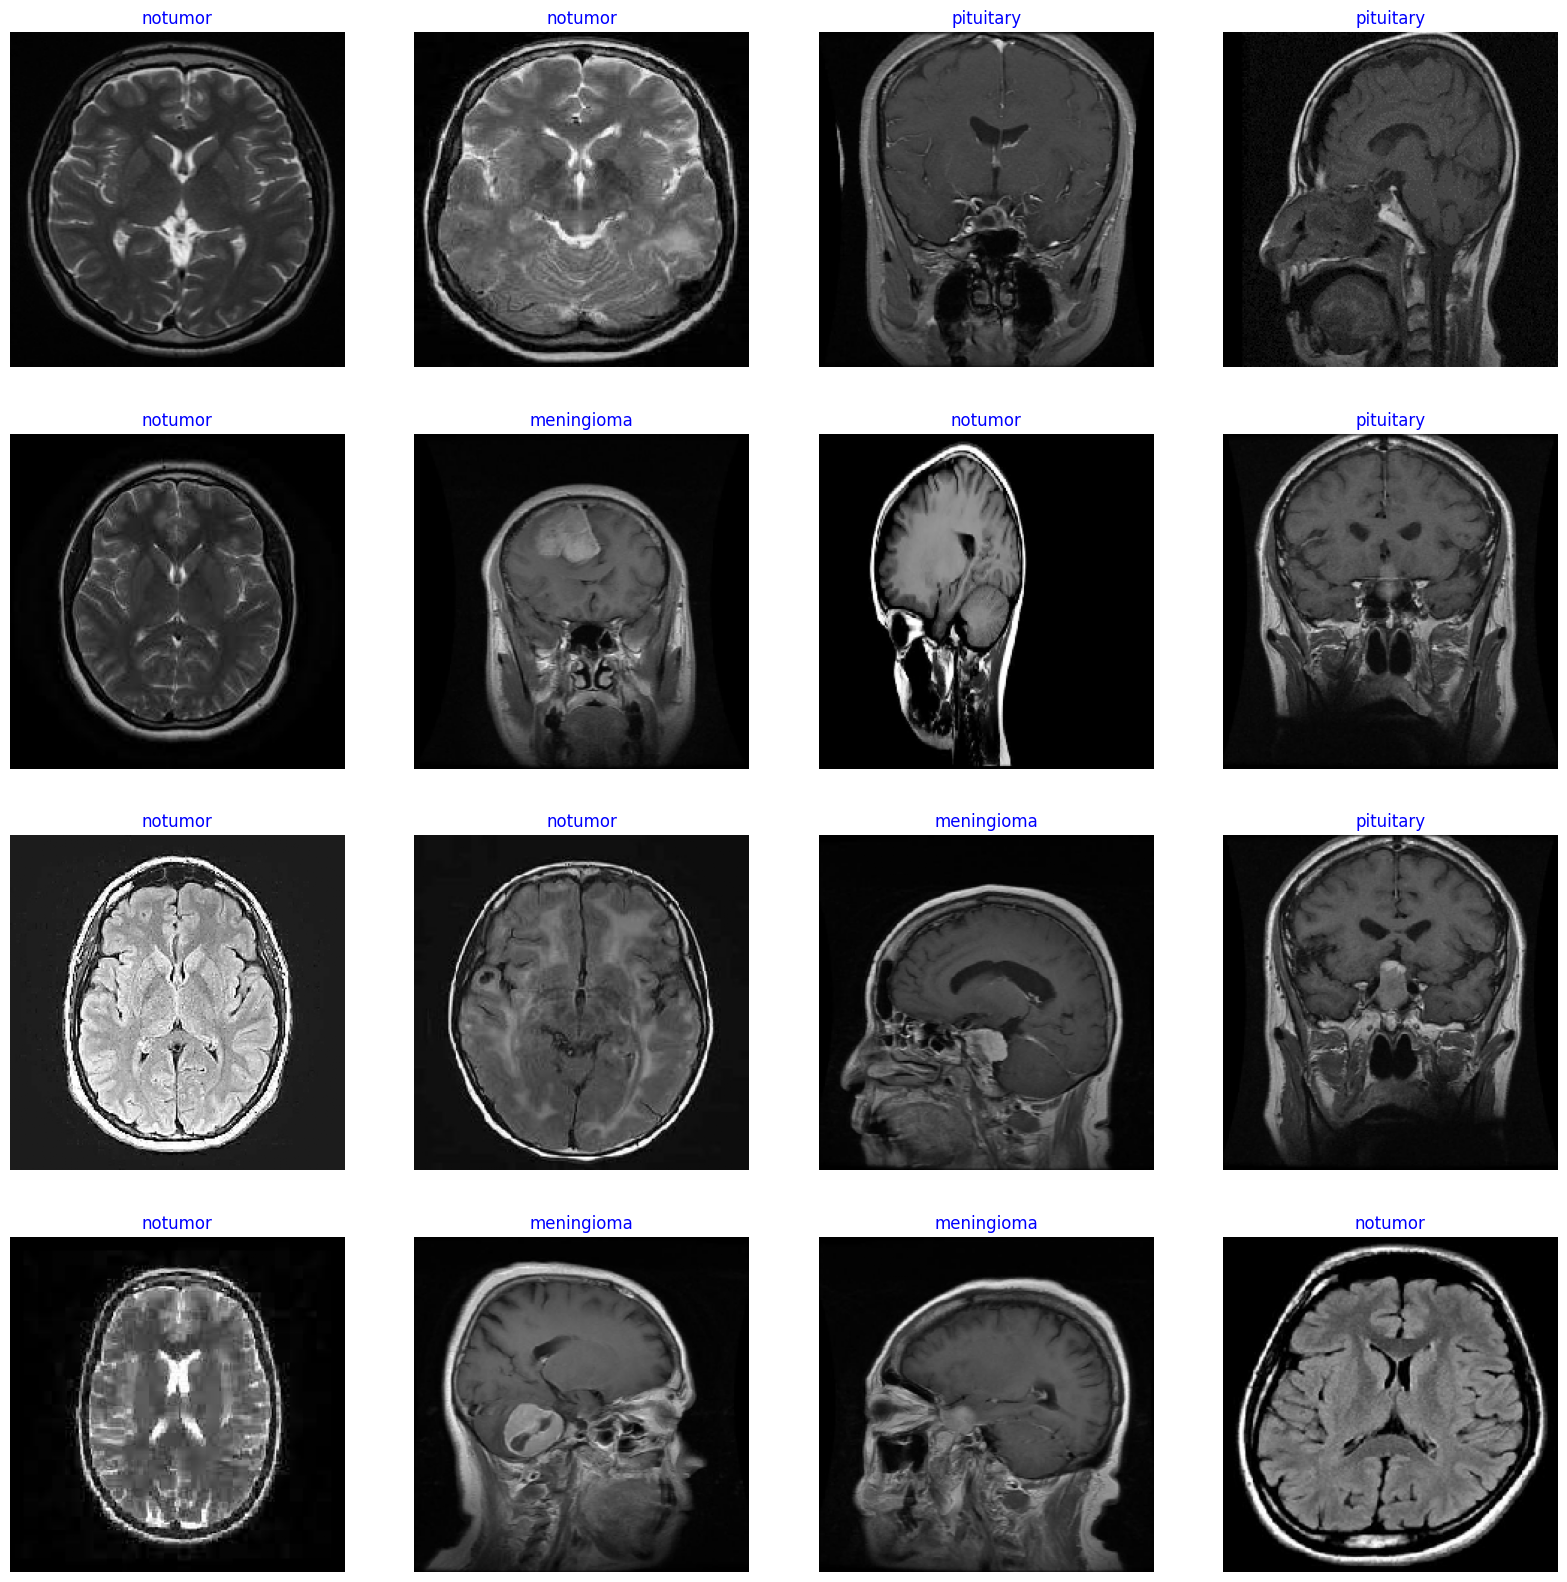

In [35]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
images, labels = next(train_gen)

plt.figure(figsize=(20,20))

for i in range(16):
  plt.subplot(4,4,i+1)
  image = images[i] / 255
  plt.imshow(image)
  index = np.argmax(labels[i])
  class_name = classes[index]
  plt.title(class_name, color="blue", fontsize=12)
  plt.axis('off')

plt.show()

In [36]:
img_shape = (img_size[0] , img_size[1] , 3)
num_class = len(classes)

base_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    include_top = False , weights = 'imagenet',
    input_shape = img_shape, pooling= 'max')

model = Sequential([
    base_model,
    BatchNormalization(axis= -1 , momentum= 0.99 , epsilon= 0.001),
    Dense(256, kernel_regularizer = regularizers.l2(0.016) , activity_regularizer = regularizers.l1(0.006),
         bias_regularizer= regularizers.l1(0.006) , activation = 'relu'),
    Dropout(rate= 0.4 , seed = 75),
    Dense(num_class , activation = 'softmax')
])

model.compile(Adamax(learning_rate = 0.001) , loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 1280)           │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 6,190,228 (23.61 MB)

 Non-trainable params: 63,168 (246.75 KB)

In [37]:
Epochs = 10

history = model.fit(
    train_gen,
    epochs=Epochs,
    validation_data=valid_gen,
    verbose=1,
    shuffle=True
)

Epoch 1/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 135s 142ms/step - accuracy: 0.5375 - loss: 10.5743 - val_accuracy: 0.3542 - val_loss: 5.4759
Epoch 2/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 35s 99ms/step - accuracy: 0.3662 - loss: 4.9655 - val_accuracy: 0.5756 - val_loss: 3.6266
Epoch 3/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 34s 95ms/step - accuracy: 0.4932 - loss: 3.3219 - val_accuracy: 0.5771 - val_loss: 2.4748
Epoch 4/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.5728 - loss: 2.3331 - val_accuracy: 0.5786 - val_loss: 1.8444
Epoch 5/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.5624 - loss: 1.7902 - val_accuracy: 0.6336 - val_loss: 1.4639
Epoch 6/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - accuracy: 0.6290 - loss: 1.4426 - val_accuracy: 0.8656 - val_loss: 1.1079
Epoch 7/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.7890 - loss: 1.1359 - val_accuracy: 0.9252 - val_loss: 0.8378
Epoch 8/10
357/357 ━━━━━━━━━━━━━━━━━━━━ 35s 97ms/step - accuracy: 0.8217 - loss: 0.937

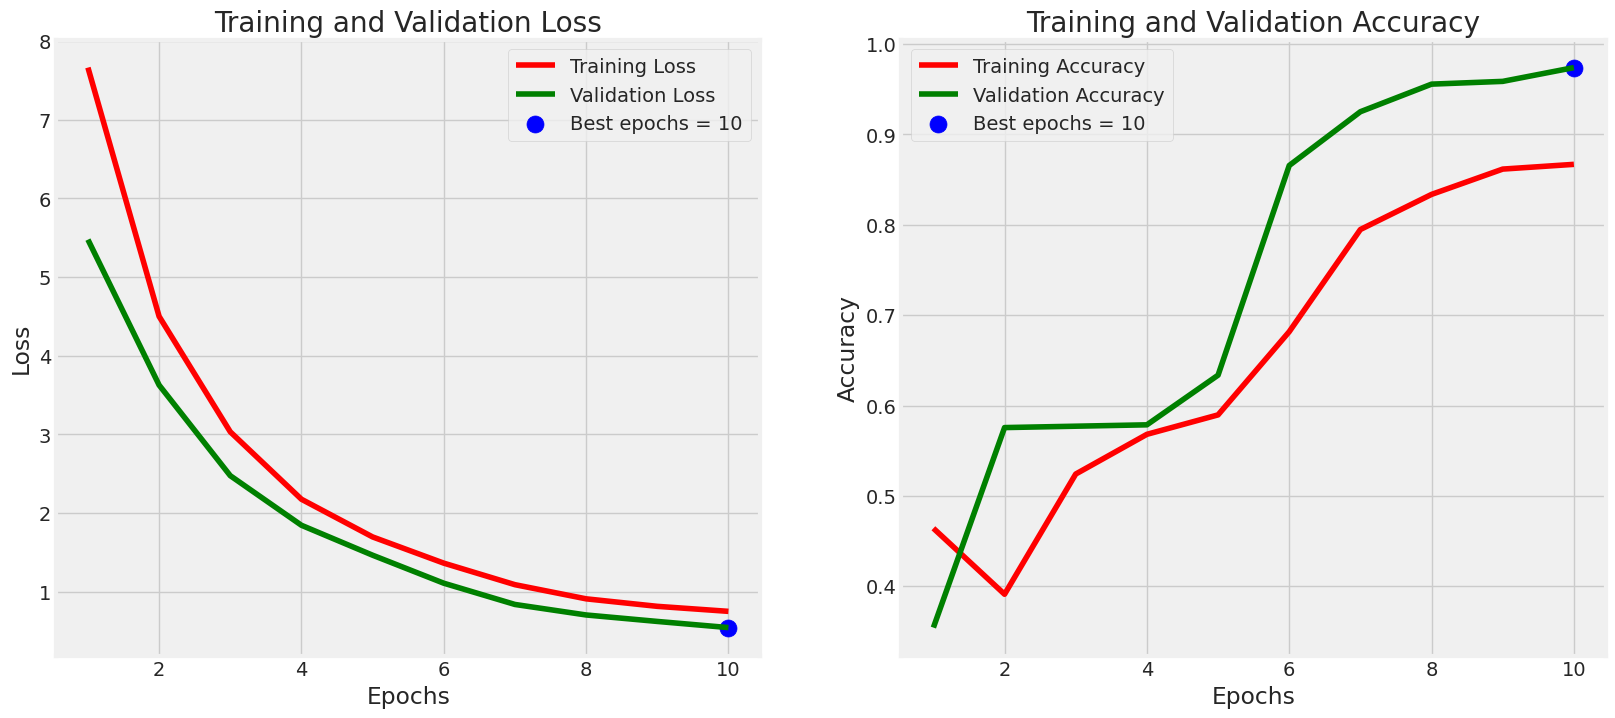

In [38]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]

index_acc = np.argmax(val_acc)
val_highest = val_acc[index_acc]

Epochs = [i+1 for i in range(len(train_acc))]

loss_label = f'Best epochs = {str(index_loss +1)}'
acc_label = f'Best epochs = {str(index_acc + 1)}'

#Training history

plt.figure(figsize= (20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(Epochs , train_loss , 'r' , label = 'Training Loss')
plt.plot(Epochs , val_loss , 'g' , label = 'Validation Loss')
plt.scatter(index_loss + 1 , val_lowest , s = 150 , c = 'blue',label = loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(Epochs , train_acc , 'r' , label = 'Training Accuracy')
plt.plot(Epochs , val_acc , 'g' , label = 'Validation Accuracy')
plt.scatter(index_acc + 1 , val_highest , s = 150 , c = 'blue',label = acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show();

In [39]:
train_score = model.evaluate(train_gen , steps =16 , verbose = 1)
valid_score = model.evaluate(valid_gen , steps = 16 , verbose = 1)
test_score = model.evaluate(test_gen , steps = 16 , verbose = 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9910 - loss: 0.5077
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9479 - loss: 0.5949
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.9829 - loss: 0.5125
Train Loss:  0.5019901394844055
Train Accuracy:  0.99609375
--------------------
Validation Loss:  0.5714537501335144
Validation Accuracy:  0.96484375
--------------------
Test Loss:  0.5318808555603027
Test Accuracy:  0.97265625


In [40]:
preds = model.predict(test_gen)

y_pred = np.argmax(preds , axis = 1)

41/41 ━━━━━━━━━━━━━━━━━━━━ 9s 70ms/step


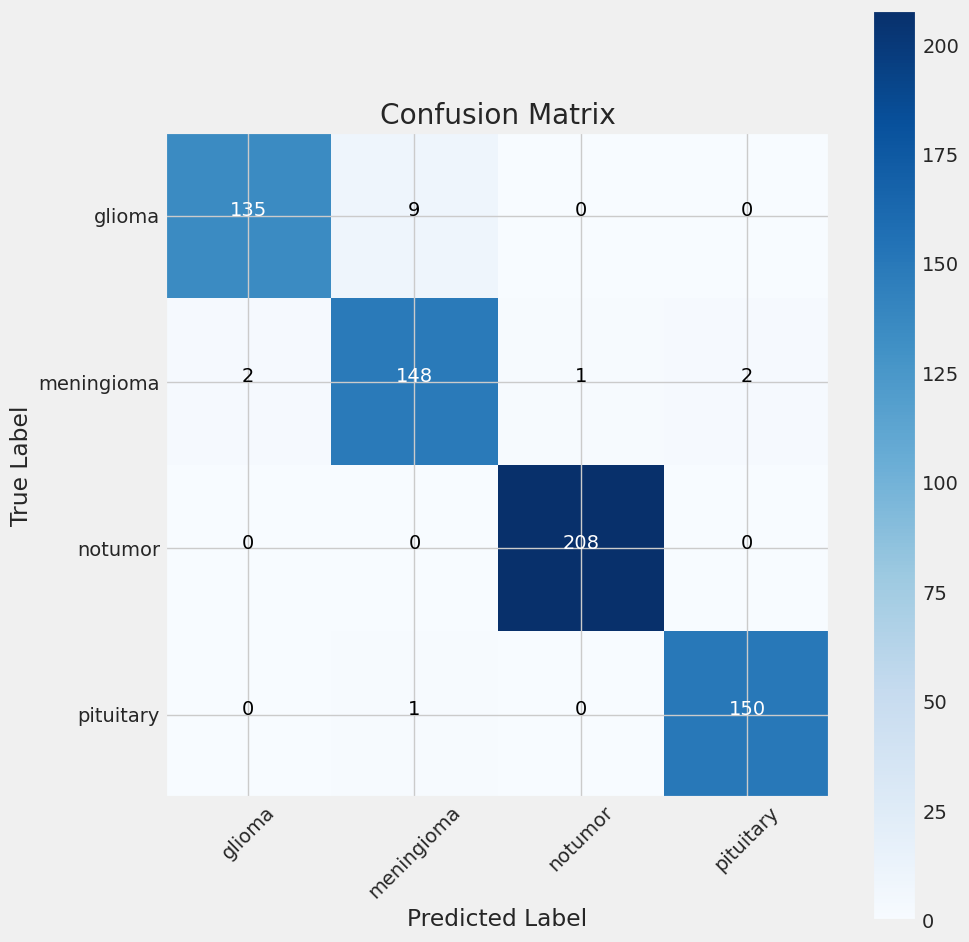

In [41]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [42]:
#Classification Report
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

      glioma       0.99      0.94      0.96       144
  meningioma       0.94      0.97      0.95       153
     notumor       1.00      1.00      1.00       208
   pituitary       0.99      0.99      0.99       151

    accuracy                           0.98       656
   macro avg       0.98      0.97      0.98       656
weighted avg       0.98      0.98      0.98       656



In [43]:
model.save("model.h5")

In [44]:
from keras.models import load_model
from keras.preprocessing import image
import numpy as np

In [45]:
model = load_model('model.h5', compile=False)
model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [58]:
gambar = tf.keras.preprocessing.image.load_img('/content/drive/MyDrive/dataset/dataset/Testing/data_test.jpg', target_size=img_size)

In [59]:
input_arr = tf.keras.preprocessing.image.img_to_array(gambar)

In [60]:
input_arr = np.array([input_arr])
prediksi = model.predict(input_arr)
predicted_class = np.argmax(prediksi, axis=-1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step


In [61]:
print(predicted_class)

[2]


In [62]:
print(classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [63]:
names = [classes[i] for i in predicted_class]
print(names)

['notumor']
